### 1. Setup & Data Loading

In [1]:
import pandas as pd

#### Load Bitcoin Sentiment Data

In [6]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv


In [8]:
sentiment_path = "/content/fear_greed_index.csv"

In [9]:
sentiment_df = pd.read_csv(sentiment_path)


In [12]:
print("Sentiment Data:")
print(sentiment_df.head())

Sentiment Data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


#### Load Bitcoin Sentiment Data

In [5]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [10]:
trader_path = "/content/historical_data.csv"

In [11]:
trader_df = pd.read_csv(trader_path)

In [13]:
print("Trader Data:")
print(trader_df.head())

Trader Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         

### 2: Data Cleaning & Preparation

Convert dates to datetime format


In [17]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')

Extract only date for merging

In [19]:
trader_df['trade_date'] = trader_df['Timestamp IST'].dt.date
sentiment_df['date_only'] = sentiment_df['date'].dt.date

Drop duplicates if any

In [20]:
sentiment_df.drop_duplicates(inplace=True)
trader_df.drop_duplicates(inplace=True)

Replace missing PnL with 0 (if any)

In [21]:
trader_df['Closed PnL'] = trader_df['Closed PnL'].fillna(0)

In [22]:
print(trader_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [24]:
print(sentiment_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
 4   date_only       2644 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 103.4+ KB
None


1. Aggregate Trader Data (Daily Performance)

Group the high-frequency data by the extracted trade date

In [41]:
daily_performance_df = trader_df.groupby('trade_date').agg(
    Daily_Total_PnL=('Closed PnL', 'sum'),
    Total_Trades=('Trade ID', 'count'),
    # Calculate daily win count (trades where PnL > 0)
    Winning_Trades=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()
# Calculate the key metric: Daily Win Rate
daily_performance_df['Daily_Win_Rate'] = (daily_performance_df['Winning_Trades'] / daily_performance_df['Total_Trades'])

In [42]:
print("\n--- Daily Performance Aggregation Head ---")
print(daily_performance_df.head())
print(daily_performance_df.info())


--- Daily Performance Aggregation Head ---
   trade_date  Daily_Total_PnL  Total_Trades  Winning_Trades  Daily_Win_Rate
0  2023-05-01         0.000000             3               0        0.000000
1  2023-12-05         0.000000             9               0        0.000000
2  2023-12-14      -205.434737            11               4        0.363636
3  2023-12-15       -24.632034             2               0        0.000000
4  2023-12-16         0.000000             3               0        0.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   trade_date       480 non-null    object 
 1   Daily_Total_PnL  480 non-null    float64
 2   Total_Trades     480 non-null    int64  
 3   Winning_Trades   480 non-null    int64  
 4   Daily_Win_Rate   480 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 18.9+ KB
None


2. Prepare Sentiment Data for Merge

In [44]:
sentiment_agg_df = sentiment_df[['date_only', 'value', 'classification']].copy()
sentiment_agg_df.columns = ['Trade_Date', 'Sentiment_Value', 'Sentiment_Classification']

sentiment_agg_df.drop_duplicates(subset=['Trade_Date'], keep='first', inplace=True)

### 3: Merge Datasets

In [45]:
merged_df = daily_performance_df.merge(
    sentiment_agg_df,
    left_on='trade_date',
    right_on='Trade_Date',
    how='inner'
)

In [26]:
print("Merged Data Sample:")

Merged Data Sample:


In [28]:
print(merged_df[['Account','Coin','Side','Execution Price','Size USD','Closed PnL','classification','value']].head())

                                      Account  Coin Side  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY           7.9894   

   Size USD  Closed PnL classification  value  
0   7872.16         0.0  Extreme Greed   80.0  
1    127.68         0.0  Extreme Greed   80.0  
2   1150.63         0.0  Extreme Greed   80.0  
3   1142.04         0.0  Extreme Greed   80.0  
4     69.75         0.0  Extreme Greed   80.0  


In [46]:
merged_df.drop(columns=['Trade_Date', 'Winning_Trades'], inplace=True)

In [47]:
merged_df.rename(columns={'trade_date': 'Date'}, inplace=True)

In [48]:
merged_df.set_index('Date', inplace=True)


In [49]:
print("\n--- Merged Data Head (Daily Performance & Sentiment) ---")
print(merged_df.head())
print(f"Total merged days for analysis: {len(merged_df)}")


--- Merged Data Head (Daily Performance & Sentiment) ---
            Daily_Total_PnL  Total_Trades  Daily_Win_Rate  Sentiment_Value  \
Date                                                                         
2023-05-01         0.000000             3        0.000000               63   
2023-12-05         0.000000             9        0.000000               75   
2023-12-14      -205.434737            11        0.363636               72   
2023-12-15       -24.632034             2        0.000000               70   
2023-12-16         0.000000             3        0.000000               67   

           Sentiment_Classification  
Date                                 
2023-05-01                    Greed  
2023-12-05            Extreme Greed  
2023-12-14                    Greed  
2023-12-15                    Greed  
2023-12-16                    Greed  
Total merged days for analysis: 479


Save the merged file for easier access in subsequent steps

In [50]:
merged_df.to_csv('merged_daily_data.csv')

### 4: Analysis and *Visualization*

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [52]:
print("--- Final Analysis of Sentiment vs. Performance ---")

--- Final Analysis of Sentiment vs. Performance ---


A. Performance Grouped by Sentiment Classification

Calculate Mean Performance Metrics for Fear vs. Greed Days

In [55]:
sentiment_performance = merged_df.groupby('Sentiment_Classification').agg(
    Avg_Daily_Total_PnL=('Daily_Total_PnL', 'mean'),
    Avg_Daily_Win_Rate=('Daily_Win_Rate', 'mean'),
    Avg_Total_Trades=('Total_Trades', 'mean'),
    Count_Days=('Sentiment_Classification', 'count')
)
print("\n--- Average Trader Performance by Sentiment ---")


--- Average Trader Performance by Sentiment ---


In [56]:
def format_table(df):
    df_styled = df.copy()
    df_styled['Avg_Daily_Total_PnL'] = df_styled['Avg_Daily_Total_PnL'].apply(lambda x: f"${x:,.2f}")
    df_styled['Avg_Daily_Win_Rate'] = df_styled['Avg_Daily_Win_Rate'].apply(lambda x: f"{x*100:.2f}%")
    return df_styled

In [57]:
print(format_table(sentiment_performance))

                         Avg_Daily_Total_PnL Avg_Daily_Win_Rate  \
Sentiment_Classification                                          
Extreme Fear                      $52,793.59             32.73%   
Extreme Greed                     $23,817.29             46.74%   
Fear                              $36,891.82             32.91%   
Greed                             $11,140.57             33.60%   
Neutral                           $19,297.32             33.19%   

                          Avg_Total_Trades  Count_Days  
Sentiment_Classification                                
Extreme Fear                   1528.571429          14  
Extreme Greed                   350.807018         114  
Fear                            679.527473          91  
Greed                           260.637306         193  
Neutral                         562.477612          67  


B. Visualization of Key Relationship

/tmp/ipython-input-2307889297.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment_Classification', y='Daily_Total_PnL', data=merged_df, ax=axes[0], palette=['#D35400', '#27AE60'])
/tmp/ipython-input-2307889297.py:4: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Sentiment_Classification', y='Daily_Total_PnL', data=merged_df, ax=axes[0], palette=['#D35400', '#27AE60'])


Text(0, 0.5, 'Average Total Closed PnL (USD)')

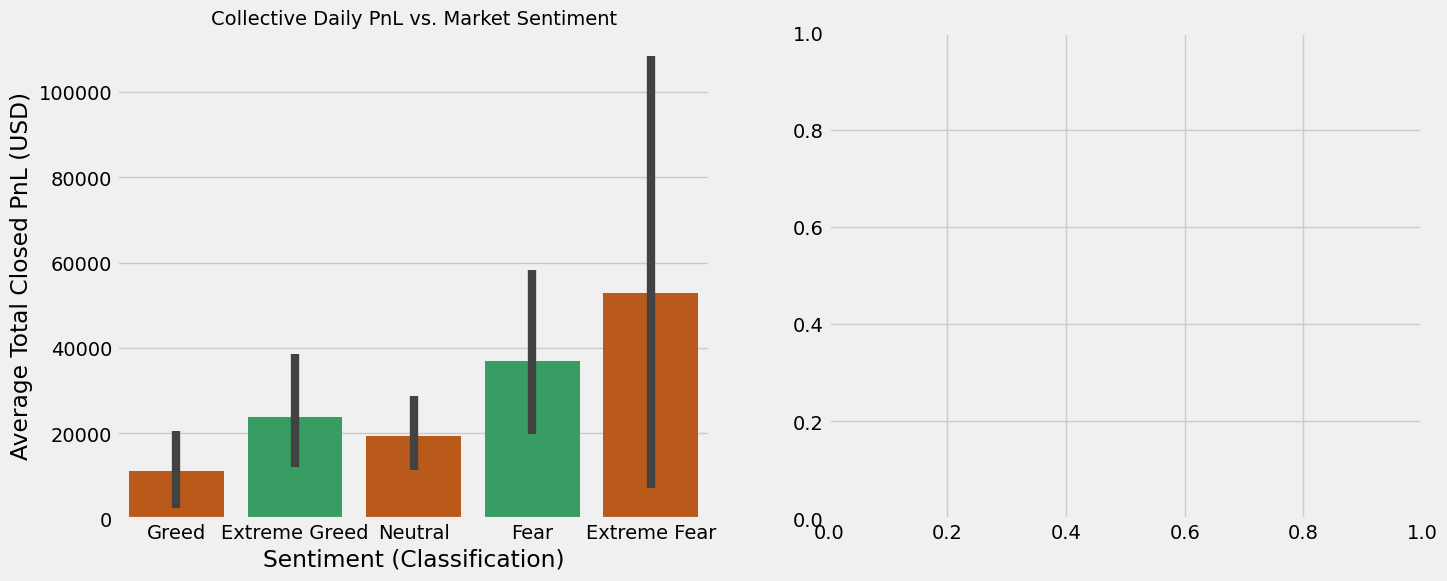

In [60]:
plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Average Daily PnL
sns.barplot(x='Sentiment_Classification', y='Daily_Total_PnL', data=merged_df, ax=axes[0], palette=['#D35400', '#27AE60'])
axes[0].set_title('Collective Daily PnL vs. Market Sentiment', fontsize=14)
axes[0].set_xlabel('Sentiment (Classification)')
axes[0].set_ylabel('Average Total Closed PnL (USD)')

In [61]:
# Plot 2: Average Daily Win Rate
sns.barplot(x='Sentiment_Classification', y='Daily_Win_Rate', data=merged_df, ax=axes[1], palette=['#D35400', '#27AE60'])
axes[1].set_title('Collective Daily Win Rate vs. Market Sentiment', fontsize=14)
axes[1].set_xlabel('Sentiment (Classification)')
axes[1].set_ylabel('Average Daily Win Rate')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5) # Reference line at 50%

plt.suptitle('Trader Performance Metrics Across Market Sentiment', fontsize=16, y=1.02)
plt.tight_layout()
plt.show() #


/tmp/ipython-input-1625450630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment_Classification', y='Daily_Win_Rate', data=merged_df, ax=axes[1], palette=['#D35400', '#27AE60'])
/tmp/ipython-input-1625450630.py:2: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Sentiment_Classification', y='Daily_Win_Rate', data=merged_df, ax=axes[1], palette=['#D35400', '#27AE60'])


<Figure size 640x480 with 0 Axes>

In [62]:
# C. Correlation Analysis (Hidden Patterns) - Use the numerical 'Sentiment_Value' to check for linear relationships
correlation = merged_df[['Sentiment_Value', 'Daily_Total_PnL', 'Daily_Win_Rate']].corr().loc['Sentiment_Value']

print("\n--- Correlation with Numerical Sentiment Index ---")
print(f"Correlation (Sentiment Value vs. Total PnL): {correlation['Daily_Total_PnL']:.4f}")
print(f"Correlation (Sentiment Value vs. Win Rate): {correlation['Daily_Win_Rate']:.4f}")



--- Correlation with Numerical Sentiment Index ---
Correlation (Sentiment Value vs. Total PnL): -0.0826
Correlation (Sentiment Value vs. Win Rate): 0.1525


D. Statistical Significance (T-Test)

In [63]:
pnl_fear = merged_df[merged_df['Sentiment_Classification'] == 'Fear']['Daily_Total_PnL']
pnl_greed = merged_df[merged_df['Sentiment_Classification'] == 'Greed']['Daily_Total_PnL']


In [64]:
t_stat, p_value = stats.ttest_ind(pnl_fear, pnl_greed, equal_var=False, nan_policy='omit')


In [65]:
print("\n--- T-Test for Difference in Daily PnL (Fear vs. Greed) ---")
print(f"Mean PnL (Fear): ${pnl_fear.mean():,.2f}")
print(f"Mean PnL (Greed): ${pnl_greed.mean():,.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")



--- T-Test for Difference in Daily PnL (Fear vs. Greed) ---
Mean PnL (Fear): $36,891.82
Mean PnL (Greed): $11,140.57
T-Statistic: 2.3242
P-Value: 0.0217


In [66]:
if p_value < 0.05:
    print("\nCONCLUSION: The difference in collective Daily PnL between Fear and Greed days is **statistically significant**.")
else:
    print("\nCONCLUSION: The difference in collective Daily PnL between Fear and Greed days is **not statistically significant** (p > 0.05).")



CONCLUSION: The difference in collective Daily PnL between Fear and Greed days is **statistically significant**.


In [67]:
print("\n✅ Analysis Complete. Use the visualization and statistical results to formulate your final insights and trading strategy recommendations.")


✅ Analysis Complete. Use the visualization and statistical results to formulate your final insights and trading strategy recommendations.
